# Mini connect tool tutorial 

## 1) Use SPICE Kernels to construct spacecraft trajectories

In [1]:
import numpy as np
from mini_connect_tool import spacecraft_coords as spc

INFO: Installing IAU_SUN PCK frame (10010) as 'spice_IAU_SUN' [sunpy.coordinates.spice]
INFO: Creating ICRF frame with SUN (10) origin [sunpy.coordinates.spice]


In [2]:
spc.check_kernel()

/Users/vreville/Library/Caches/sunpy/de430.bsp [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 199, 299, 301, 399]
['1549-12-30T23:59:18.8159', '2650-01-24T23:58:50.8157'] MERCURY BARYCENTER , NAIF ID = 1
['1549-12-30T23:59:18.8159', '2650-01-24T23:58:50.8157'] VENUS BARYCENTER , NAIF ID = 2
['1549-12-30T23:59:18.8159', '2650-01-24T23:58:50.8157'] EARTH-MOON BARYCENTER , NAIF ID = 3
['1549-12-30T23:59:18.8159', '2650-01-24T23:58:50.8157'] MARS BARYCENTER , NAIF ID = 4
['1549-12-30T23:59:18.8159', '2650-01-24T23:58:50.8157'] JUPITER BARYCENTER , NAIF ID = 5
['1549-12-30T23:59:18.8159', '2650-01-24T23:58:50.8157'] SATURN BARYCENTER , NAIF ID = 6
['1549-12-30T23:59:18.8159', '2650-01-24T23:58:50.8157'] URANUS BARYCENTER , NAIF ID = 7
['1549-12-30T23:59:18.8159', '2650-01-24T23:58:50.8157'] NEPTUNE BARYCENTER , NAIF ID = 8
['1549-12-30T23:59:18.8159', '2650-01-24T23:58:50.8157'] PLUTO BARYCENTER , NAIF ID = 9
['1549-12-30T23:59:18.8159', '2650-01-24T23:58:50.8157'] SUN , NAIF ID = 10
['1549-12-30T23:59:18

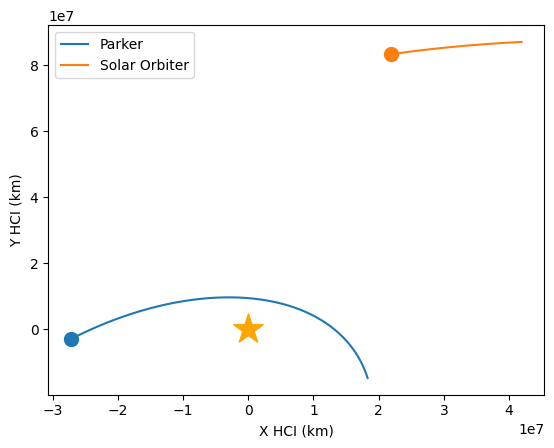

In [3]:
from datetime import datetime, timedelta

import numpy as np
from mini_connect_tool import spacecraft_coords as spc

# Times (Refers to Rivera, Badman et al. 2024, Science)                                                                                                                                                                   
start = "2022-02-23T00:00:00"
stop  = "2022-02-28T23:59:59"

t1=datetime.strptime(start, "%Y-%m-%dT%H:%M:%S")
t2=datetime.strptime(stop,  "%Y-%m-%dT%H:%M:%S")

psp=spc.spacecraft_coords(t1,t2,sc='SPP',delta=1)
solo=spc.spacecraft_coords(t1,t2,sc='Solar Orbiter', delta=1)

fig,ax=plt.subplots(1,1)

ax.plot(psp.xsc, psp.ysc, label="Parker")
ax.plot(solo.xsc, solo.ysc, label="Solar Orbiter")
ax.scatter(psp.xsc[-1], psp.ysc[-1], s=100)
ax.scatter(solo.xsc[-1], solo.ysc[-1], s=100)
ax.scatter([0], [0], marker="*", s=500, color="orange")

ax.set_xlabel("X HCI (km)")
ax.set_ylabel("Y HCI (km)")
ax.legend(loc="best")

plt.show()

## Exercise : increase the time interval to observe the trajectories. What frame are we into ? What are these trajectories ?

# Let's now work in the Carrington (solar rotating) frame

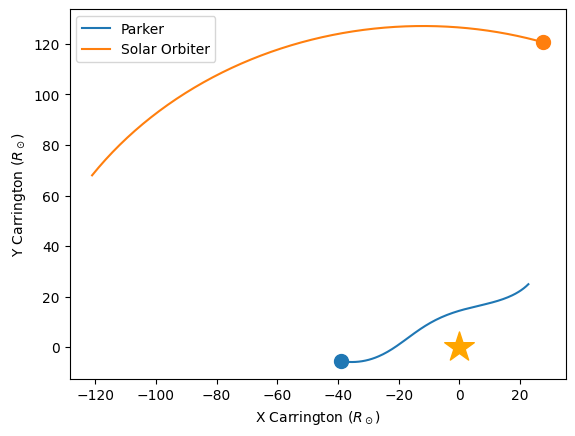

In [4]:
fig,ax=plt.subplots(1,1)

psp.xcr=psp.rsc*np.cos(psp.psc)*np.sin(psp.tsc)
psp.ycr=psp.rsc*np.sin(psp.psc)*np.sin(psp.tsc)
psp.zcr=psp.rsc*np.cos(psp.tsc)

ax.plot(psp.xcr, psp.ycr, label="Parker")

solo.xcr=solo.rsc*np.cos(solo.psc)*np.sin(solo.tsc)
solo.ycr=solo.rsc*np.sin(solo.psc)*np.sin(solo.tsc)
solo.zcr=solo.rsc*np.cos(solo.tsc)


ax.plot(solo.xcr, solo.ycr, label="Solar Orbiter")
ax.scatter(psp.xcr[-1], psp.ycr[-1], s=100)
ax.scatter(solo.xcr[-1], solo.ycr[-1], s=100)
ax.scatter([0], [0], marker="*", s=500, color="orange")

ax.set_xlabel(r"X Carrington $(R_\odot)$")
ax.set_ylabel(r"Y Carrington $(R_\odot)$")
ax.legend(loc="best")

plt.show()

## Plot the Parker spiral

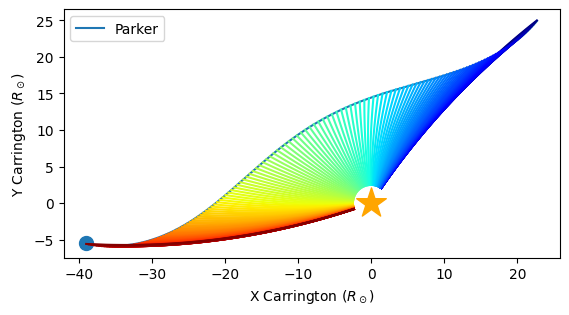

In [5]:
import matplotlib.cm as cm

fig,ax=plt.subplots(1,1)

ax.plot(psp.xcr, psp.ycr, label="Parker")
ax.scatter(psp.xcr[-1], psp.ycr[-1], s=100)
ax.scatter([0], [0], marker="*", s=500, color="orange")

ax.set_xlabel(r"X Carrington $(R_\odot)$")
ax.set_ylabel(r"Y Carrington $(R_\odot)$")
ax.legend(loc="best")

# First with a constant wind speed
vsw = 400 # km/s
Rss=2.5

for ii in range(len(psp.dt)):
    rads=np.linspace(psp.rsc[ii], Rss, 100)
    ps_angle=np.array([spc.ParkerSpiral(psp.psc[ii], rads[0], Rss=rads[1], Vsw=vsw)])
    for kk,rr in enumerate(rads[1:]):
        ps_angle=np.append(ps_angle, spc.ParkerSpiral(ps_angle[-1], rads[kk], Rss=rads[kk+1], Vsw=vsw))

    ax.plot(rads*np.cos(ps_angle), rads*np.sin(ps_angle), color=cm.jet(ii/len(psp.dt)))

ax.set_aspect('equal')
plt.show()

## Change the solar wind speed. What is happening?

## Now with the measured solar wind speed

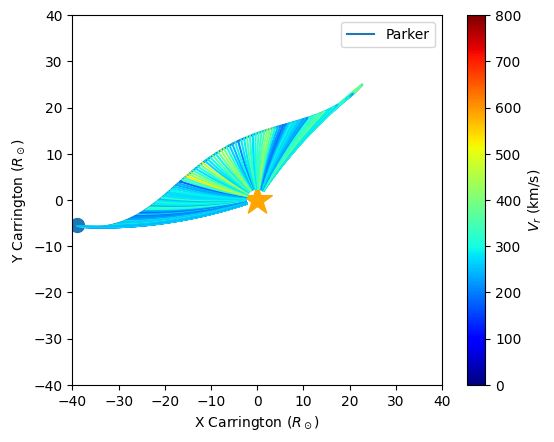

In [9]:
import speasy as spz
from mini_connect_tool import timeseries as ts
import matplotlib as mpl

v_rtn_psp=spz.get_data("amda/psp_spi_Hv", t1, t2)
v_rtn_psp=v_rtn_psp.to_dataframe().bfill()

ts_psp=np.array([tt.timestamp() for tt in psp.dt])
v_rtn_interp=ts.interp(v_rtn_psp, ts_psp*1e9) # nano second ts

fig,ax=plt.subplots(1,1)

ax.plot(psp.xcr, psp.ycr, label="Parker")
ax.scatter(psp.xcr[-1], psp.ycr[-1], s=100)
ax.scatter([0], [0], marker="*", s=500, color="orange")

ax.set_xlabel(r"X Carrington $(R_\odot)$")
ax.set_ylabel(r"Y Carrington $(R_\odot)$")
ax.legend(loc="best")

Rss=2.5

for ii in range(len(psp.dt)):
    rads=np.linspace(psp.rsc[ii], Rss, 100)
    local_ws=v_rtn_interp.values[ii][0]
    ps_angle=np.array([spc.ParkerSpiral(psp.psc[ii], rads[0], Rss=rads[1], Vsw=local_ws)])
    for kk,rr in enumerate(rads[1:]):
        ps_angle=np.append(ps_angle, spc.ParkerSpiral(ps_angle[-1], rads[kk], Rss=rads[kk+1], Vsw=vsw))

    ax.plot(rads*np.cos(ps_angle), rads*np.sin(ps_angle), color=cm.jet(local_ws/800))

fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(0, 800), cmap='jet'),
             ax=ax, orientation='vertical', label=r'$V_r$ (km/s)')

ax.set_aspect('equal')
ax.set_xlim([-40,40])
ax.set_ylim([-40,40])
plt.show()


# 2) Build the coronal PFSS solution

In [7]:
from mini_connect_tool import mini_connect_tool as mct
from mini_connect_tool import load_maps as load

print(t1,t2)

t1_map = t1 - timedelta(days=3) # Extend three days in the past to account for sw propagation                                                                                
t2_map = t2

adapt_dir="../data/adapt_carrington/"
map_files, map_times = load.dl_adapt_carrington_maps(t1_map, t2_map, cadence_hours=24, adapt_dir=adapt_dir)

2022-02-23 00:00:00 2022-02-28 23:59:59
File ../data/adapt_carrington/adapt40311_044012_202202201200_i00013600n1.fts already exists, skipping download.
File ../data/adapt_carrington/adapt40311_044012_202202211200_i00013600n1.fts already exists, skipping download.
File ../data/adapt_carrington/adapt40311_044012_202202221200_i00005600n1.fts already exists, skipping download.
File ../data/adapt_carrington/adapt40311_044012_202202231200_i00005600n1.fts already exists, skipping download.
File ../data/adapt_carrington/adapt40311_044012_202202241200_i00013600n1.fts already exists, skipping download.
File ../data/adapt_carrington/adapt40311_044012_202202251200_i00013600n1.fts already exists, skipping download.
File ../data/adapt_carrington/adapt40311_044012_202202261200_i00013600n1.fts already exists, skipping download.
File ../data/adapt_carrington/adapt40311_044012_202202271200_i00014600n1.fts already exists, skipping download.
File ../data/adapt_carrington/adapt40311_044012_202202281200_i00

In [11]:
print(map_files)

['adapt40311_044012_202202201200_i00013600n1.fts', 'adapt40311_044012_202202211200_i00013600n1.fts', 'adapt40311_044012_202202221200_i00005600n1.fts', 'adapt40311_044012_202202231200_i00005600n1.fts', 'adapt40311_044012_202202241200_i00013600n1.fts', 'adapt40311_044012_202202251200_i00013600n1.fts', 'adapt40311_044012_202202261200_i00013600n1.fts', 'adapt40311_044012_202202271200_i00014600n1.fts', 'adapt40311_044012_202202281200_i00004500n1.fts']


In [13]:
rss=2.5 # Source surface radius                                                                                                                                          
lmax=15  # Spherical harmonics decomposition max degree                                                                                                                       

maps_time, theta, phi, rad, brr, btt, bpp = mct.build_mag_fields(adapt_dir, map_files, rss=rss, lmax=lmax, real=0)

  0%|                                                                                             | 0/1 [00:00<?, ?it/s]
                                                                                                                        
  0%|                                                                                             | 0/2 [00:00<?, ?it/s]
                                                                                                                        
  0%|                                                                                             | 0/4 [00:00<?, ?it/s]
                                                                                                                        
 80%|████████████████████████████████████████████████████████████████████                 | 4/5 [00:00<00:00, 35.93it/s]
                                                                                                                        
 86%|███████████████████████████

In [14]:
# Select one time

print(brr.shape)
print(maps_time)
idx=0
br=brr[idx]
bt=btt[idx]
bp=bpp[idx]


(9, 100, 180, 360)
[datetime.datetime(2022, 2, 20, 12, 0)
 datetime.datetime(2022, 2, 21, 12, 0)
 datetime.datetime(2022, 2, 22, 12, 0)
 datetime.datetime(2022, 2, 23, 12, 0)
 datetime.datetime(2022, 2, 24, 12, 0)
 datetime.datetime(2022, 2, 25, 12, 0)
 datetime.datetime(2022, 2, 26, 12, 0)
 datetime.datetime(2022, 2, 27, 12, 0)
 datetime.datetime(2022, 2, 28, 12, 0)]


In [15]:
import pyvista as pv
pv.set_jupyter_backend('trame')

def spherical_to_cartesian(tt,pp,vr,vt,vp):
    VX=np.sin(tt)*np.cos(pp)*vr + np.cos(tt)*np.cos(pp)*vt - np.sin(pp)*vp
    VY=np.sin(tt)*np.sin(pp)*vr + np.cos(tt)*np.sin(pp)*vt + np.cos(pp)*vp
    VZ=           np.cos(tt)*vr -            np.sin(tt)*vt
    return VX,VY,VZ
    
seed_points=[]
r0=1.01
npoints=15

for ii,pp in enumerate(np.linspace(0,2*np.pi, 2*npoints)):
    for jj,tt in enumerate(np.linspace(0,np.pi, npoints)):
        x=r0*np.sin(tt)*np.cos(pp)
        y=r0*np.sin(tt)*np.sin(pp)
        z=r0*np.cos(tt)
        seed_points.append([x,y,z])

r3d,th3d,ph3d = np.meshgrid(rad,theta,phi,indexing='ij')
x3d = r3d * np.sin(th3d)*np.cos(ph3d)
y3d = r3d * np.sin(th3d)*np.sin(ph3d)
z3d = r3d * np.cos(th3d)

mesh = pv.StructuredGrid(x3d,y3d,z3d)
Bvec = np.stack([v.flatten(order='F') for v in spherical_to_cartesian(th3d,ph3d,br,bt,bp)]).T
mesh["B"] = Bvec
mesh['Rs'] = (r3d).T.flatten()
mesh['mag. field (G)'] = (br).T.flatten()
mesh["sB"] = np.sign(br).T.flatten()
surf=mesh.contour([r0], scalars='Rs')

seeds=pv.PolyData(seed_points)
st = mesh.streamlines_from_source(seeds,
                                  max_length=1000,
                                  vectors='B',
                                  initial_step_length=0.1,
                                  step_unit="cl",
                                  integration_direction="both")

p = pv.Plotter()

p.background_color="w"
cmax=np.abs(br[0,:,:]).max()
cmap="bwr"

p.add_mesh(surf,scalars='mag. field (G)',cmap=cmap,clim=[-cmax,cmax],opacity=1.0)
p.add_mesh(st.tube(radius=0.01),scalars='sB',cmap='bwr',show_scalar_bar=False)
p.show()

Widget(value='<iframe src="http://localhost:54752/index.html?ui=P_0x1442daf90_0&reconnect=auto" class="pyvista…

# 3) Compute the source points

In [16]:
# Compute the connectitivity field lines

coords, vsws, br_pfss, fieldlines, maps_indices, sun_times = mct.connect(maps_time, v_rtn_psp.vr, rad, theta, phi, brr, btt, bpp, t1, t2, sc="SPP", lag="SW")

capi_return is NULL
Call-back cb_f_in_dvode__user__routines failed.
capi_return is NULL
Call-back cb_f_in_dvode__user__routines failed.
capi_return is NULL
Call-back cb_f_in_dvode__user__routines failed.
capi_return is NULL
Call-back cb_f_in_dvode__user__routines failed.
capi_return is NULL
Call-back cb_f_in_dvode__user__routines failed.
capi_return is NULL
Call-back cb_f_in_dvode__user__routines failed.
capi_return is NULL
Call-back cb_f_in_dvode__user__routines failed.
capi_return is NULL
Call-back cb_f_in_dvode__user__routines failed.
capi_return is NULL
Call-back cb_f_in_dvode__user__routines failed.
capi_return is NULL
Call-back cb_f_in_dvode__user__routines failed.
capi_return is NULL
Call-back cb_f_in_dvode__user__routines failed.
capi_return is NULL
Call-back cb_f_in_dvode__user__routines failed.
capi_return is NULL
Call-back cb_f_in_dvode__user__routines failed.
capi_return is NULL
Call-back cb_f_in_dvode__user__routines failed.
capi_return is NULL
Call-back cb_f_in_dvode__use

In [17]:
# Compute the source points of Parker Solar Probe

p = pv.Plotter()

p.background_color="w"
cmax=np.abs(br[0,:,:]).max()
cmap="bwr"

p.add_mesh(surf,scalars='mag. field (G)',cmap=cmap,clim=[-cmax,cmax],opacity=1.0)

for ii,fl in enumerate(fieldlines):
    fx=fl[0][0]
    fy=fl[0][1]
    fz=fl[0][2]

    local_ws=v_rtn_interp.values[ii][0]

    streamline=pv.PolyData(np.array([fx,fy,fz]).T)
    p.add_mesh(streamline, color=cm.jet(local_ws/800))


p.show()

Widget(value='<iframe src="http://localhost:54752/index.html?ui=P_0x145e73750_1&reconnect=auto" class="pyvista…

# Exercise : do the same for Solar Orbiter and compare the footpoints. When are the spacecraft in conjunction? 

In [18]:
# Plot source points in context

lon_psp, lat_psp, frs, fexps, bsurfs = mct.compute_expansion(coords, fieldlines, maps_indices, rad, theta, phi, brr, btt, bpp)
sdo_files, sdo_times = load.dl_sdo_carrington_maps(map_times)


File /Users/vreville/Codes/mini_connect_tool/mini_connect_tool/../data/sdo_carrington/AIA193_2022-02-20T12:00:00.png already exists, skipping download.
File /Users/vreville/Codes/mini_connect_tool/mini_connect_tool/../data/sdo_carrington/AIA193_2022-02-21T12:00:00.png already exists, skipping download.
File /Users/vreville/Codes/mini_connect_tool/mini_connect_tool/../data/sdo_carrington/AIA193_2022-02-22T12:00:00.png already exists, skipping download.
File /Users/vreville/Codes/mini_connect_tool/mini_connect_tool/../data/sdo_carrington/AIA193_2022-02-23T12:00:00.png already exists, skipping download.
File /Users/vreville/Codes/mini_connect_tool/mini_connect_tool/../data/sdo_carrington/AIA193_2022-02-24T12:00:00.png already exists, skipping download.
File /Users/vreville/Codes/mini_connect_tool/mini_connect_tool/../data/sdo_carrington/AIA193_2022-02-25T12:00:00.png already exists, skipping download.
File /Users/vreville/Codes/mini_connect_tool/mini_connect_tool/../data/sdo_carrington/AI

In [19]:
b_rtn_psp = spz.get_data("amda/psp_b_1min", start, stop)
b_rtn_psp = b_rtn_psp.to_dataframe()

In [20]:
# Choose a reference time

print(len(maps_indices), len(coords.dt))
dt_ref = datetime(2022,2,26,12,0,0)
id_ref=np.argmin(np.abs(np.array(coords.dt)-dt_ref))
print(id_ref)


144 144
84


In [22]:
from PIL import Image
import sunpy.visualization.colormaps
from matplotlib.colors import to_rgb

fig,((ax1,ax2),(ax3,ax4))=plt.subplots(2,2,figsize=(14,9))
ax1.scatter(b_rtn_psp.index, b_rtn_psp.br, s=0.5, color="black", alpha=0.1)

ax1.plot(coords.dt[:id_ref],br_pfss[:id_ref],linewidth=2, color="C0", label="PSP")
ax1.plot(coords.dt,np.zeros(len(br_pfss)),color="black")
ax1.set_xlim([coords.dt[0],coords.dt[-1]])
ax1.set_yscale("symlog")
ax1.set_ylabel(r"$B_r$ (nT) PSP", fontsize=15)
ax1.legend(loc="best")

ax3.plot(v_rtn_psp.index, v_rtn_psp.vr, color="black")
ax3.set_ylabel(r"$V_r$ (km/s)", fontsize=15)
ax3.set_ylim([0,v_rtn_psp.vr.max()*1.5])

maxb=np.max(np.abs(brr[maps_indices[id_ref],0,:,:]))
ax2.pcolormesh(phi*180/np.pi,(np.pi/2-theta)*180/np.pi,brr[maps_indices[id_ref],0,:,:],cmap="bwr", vmin=-maxb, vmax=maxb)
ax2.contour(phi*180/np.pi,(np.pi/2-theta)*180/np.pi,brr[maps_indices[id_ref],-1,:,:],levels=[0.0],colors="black")

ax2.annotate("{}".format(maps_time[maps_indices[id_ref]]), (20, 75), color="black")
ax2.set_title("Suntime = {}".format(sun_times[id_ref]))

sdoidx=np.argmin(np.abs(np.array(sdo_times)-maps_time[maps_indices[ii]]))
sdo_file=sdo_files[sdoidx]
sdoimg=Image.open(sdo_file)
sdoimg=sdoimg.convert("L")
sdoimg=np.array(sdoimg)

crlon=np.linspace(0,360,sdoimg.shape[1]+1)
crlat=np.linspace(-90,90,sdoimg.shape[0]+1)

ax4.pcolormesh(crlon, crlat, sdoimg[::-1,:], cmap="sdoaia193")
ax4.set_ylim([-80,80])
ax4.annotate("{}".format(sdo_times[sdoidx].isoformat(timespec="seconds")), (20, 65), color="red")
ax4.set_ylim([-80,80])

idx0=max(0,ii+1-10)
r, g, b = to_rgb("C0")
color=[(r,g,b,alpha) for alpha in np.linspace(0,1,len(lat_psp[idx0:ii+1]))]

ax2.scatter(lon_psp[idx0:ii+1], lat_psp[idx0:ii+1], color=color)
ax2.scatter(lon_psp[ii], lat_psp[ii], color="C0", edgecolors="black")

ax4.scatter(lon_psp[idx0:ii+1], lat_psp[idx0:ii+1], color=color)
ax4.scatter(lon_psp[ii], lat_psp[ii], color="C0", edgecolors="black")
ax4.set_title(r"AIA 193 Carrington", fontsize=15)
fig.suptitle("SC time = {}".format(dt_ref))

fig.autofmt_xdate()
plt.show()

OverflowError: int too big to convert

Error in callback <function _draw_all_if_interactive at 0x10a6e75e0> (for post_execute), with arguments args (),kwargs {}:


OverflowError: int too big to convert

OverflowError: int too big to convert

<Figure size 1400x900 with 4 Axes>

## Exercise : restart from 3) using the EM lag. Do you notice any difference? 